# ResNet-18

Here we are training the ResNet-18, trying out how using a pretrained model, data augmentation, regularization and LR scheduler affect the performance.<br>
We picked ResNet-18 for it's smaller size as the dataset is not big enough and we have problem with overfitting.

In [2]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

### ResNet-18 basic
- No pretraining
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 45.98% | Val: 44.44% | LR: 0.000100
Epoch 2/10 | Train: 58.61% | Val: 37.40% | LR: 0.000100
Epoch 3/10 | Train: 68.00% | Val: 45.26% | LR: 0.000100
Epoch 4/10 | Train: 82.22% | Val: 45.80% | LR: 0.000100
Epoch 5/10 | Train: 92.36% | Val: 45.12% | LR: 0.000100
Epoch 6/10 | Train: 96.21% | Val: 48.51% | LR: 0.000100
Epoch 7/10 | Train: 98.25% | Val: 50.00% | LR: 0.000100
Epoch 8/10 | Train: 99.52% | Val: 47.29% | LR: 0.000100
Epoch 9/10 | Train: 99.37% | Val: 50.14% | LR: 0.000100
Epoch 10/10 | Train: 99.22% | Val: 41.06% | LR: 0.000100


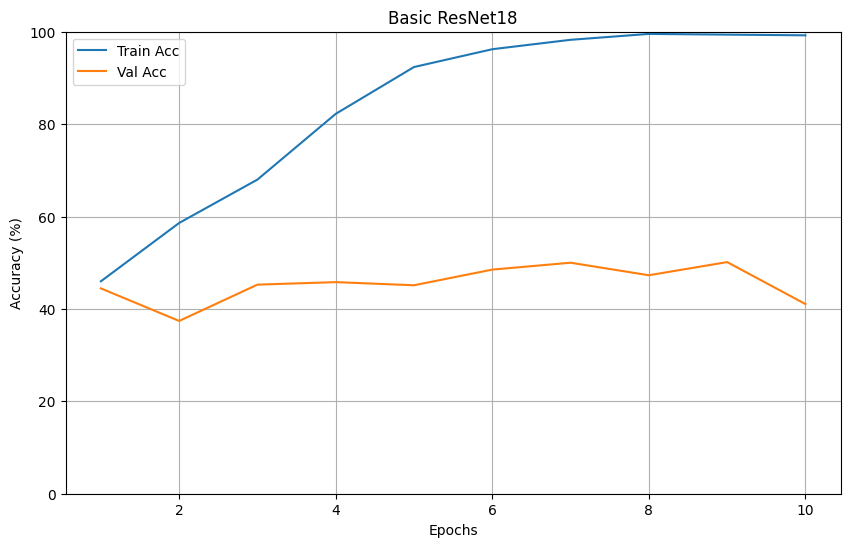


Final Test Accuracy: 49.02%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Basic ResNet18")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ResNet-18

- Using a pretrained model
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 50.14% | Val: 48.78% | LR: 0.000100
Epoch 2/10 | Train: 66.52% | Val: 54.47% | LR: 0.000100
Epoch 3/10 | Train: 78.56% | Val: 52.57% | LR: 0.000100
Epoch 4/10 | Train: 90.12% | Val: 53.39% | LR: 0.000100
Epoch 5/10 | Train: 94.38% | Val: 56.50% | LR: 0.000100
Epoch 6/10 | Train: 97.40% | Val: 55.42% | LR: 0.000100
Epoch 7/10 | Train: 97.15% | Val: 57.99% | LR: 0.000100
Epoch 8/10 | Train: 98.90% | Val: 55.69% | LR: 0.000100
Epoch 9/10 | Train: 94.62% | Val: 54.20% | LR: 0.000100
Epoch 10/10 | Train: 97.44% | Val: 53.93% | LR: 0.000100


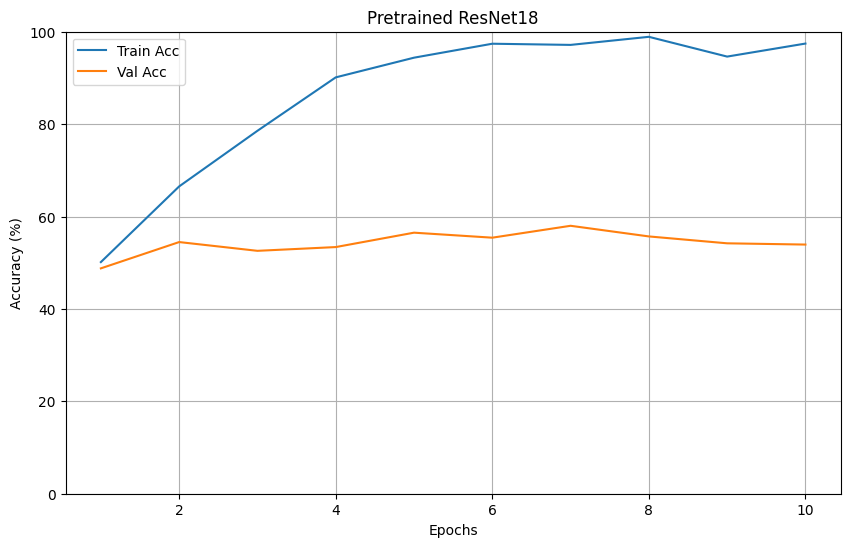


Final Test Accuracy: 59.71%


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Pretrained ResNet18")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ResNet-18 with regularization

- Using a pretrained model
- Using augmentation and regularization
- No LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/20 | Train: 36.26% | Val: 46.07% | LR: 0.000100
Epoch 2/20 | Train: 46.54% | Val: 50.14% | LR: 0.000100
Epoch 3/20 | Train: 51.49% | Val: 52.71% | LR: 0.000100
Epoch 4/20 | Train: 56.26% | Val: 53.66% | LR: 0.000100
Epoch 5/20 | Train: 59.47% | Val: 56.78% | LR: 0.000100
Epoch 6/20 | Train: 61.80% | Val: 55.96% | LR: 0.000100
Epoch 7/20 | Train: 65.18% | Val: 58.67% | LR: 0.000100
Epoch 8/20 | Train: 69.10% | Val: 57.32% | LR: 0.000100
Epoch 9/20 | Train: 70.98% | Val: 55.69% | LR: 0.000100
Epoch 10/20 | Train: 75.08% | Val: 60.03% | LR: 0.000100
Epoch 11/20 | Train: 77.95% | Val: 54.47% | LR: 0.000100
Epoch 12/20 | Train: 79.71% | Val: 55.28% | LR: 0.000100
Epoch 13/20 | Train: 82.99% | Val: 57.45% | LR: 0.000100
Epoch 14/20 | Train: 85.04% | Val: 55.83% | LR: 0.000100
Epoch 15/20 | Train: 87.10% | Val: 54.61% | LR: 0.000100
Epoch 16/20 | Train: 87.62% | Val: 59.08% | LR: 0.000100
Epoch 17/20 | Train: 89.13% | Val: 57.18% | LR: 0.000100
Epoch 18/20 | Train: 91.00% | Val: 53.12

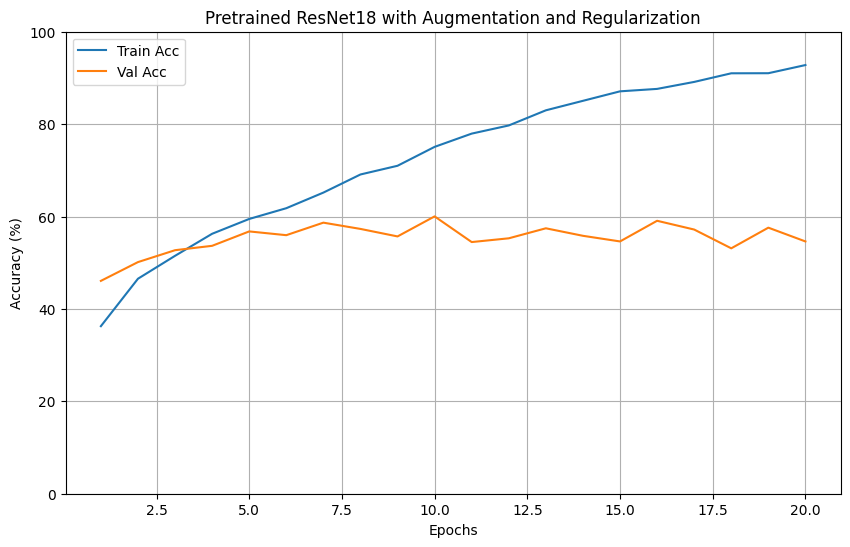


Final Test Accuracy: 55.41%


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=20)

plot_history(history, "Pretrained ResNet18 with Augmentation and Regularization")

test_accuracy = evaluate_model(model, test_loader)

### ResNet-18 final version (using everything)

- Using a pretrained model
- Using augmentation and regularization
- Using LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/30 | Train: 36.23% | Val: 44.99% | LR: 0.000100
Epoch 2/30 | Train: 45.72% | Val: 44.99% | LR: 0.000100
Epoch 3/30 | Train: 51.49% | Val: 53.12% | LR: 0.000100
Epoch 4/30 | Train: 54.74% | Val: 54.34% | LR: 0.000100
Epoch 5/30 | Train: 58.08% | Val: 54.88% | LR: 0.000100
Epoch 6/30 | Train: 61.38% | Val: 56.37% | LR: 0.000100
Epoch 7/30 | Train: 65.06% | Val: 52.98% | LR: 0.000100
Epoch 8/30 | Train: 67.79% | Val: 55.28% | LR: 0.000100
Epoch 9/30 | Train: 70.58% | Val: 53.39% | LR: 0.000050
Epoch 10/30 | Train: 78.18% | Val: 56.23% | LR: 0.000050
Epoch 11/30 | Train: 80.15% | Val: 56.91% | LR: 0.000050
Epoch 12/30 | Train: 82.82% | Val: 56.64% | LR: 0.000050
Epoch 13/30 | Train: 85.65% | Val: 57.99% | LR: 0.000050
Epoch 14/30 | Train: 86.69% | Val: 57.86% | LR: 0.000050
Epoch 15/30 | Train: 88.95% | Val: 55.28% | LR: 0.000050
Epoch 16/30 | Train: 90.02% | Val: 58.40% | LR: 0.000050
Epoch 17/30 | Train: 90.46% | Val: 56.37% | LR: 0.000050
Epoch 18/30 | Train: 91.58% | Val: 56.50

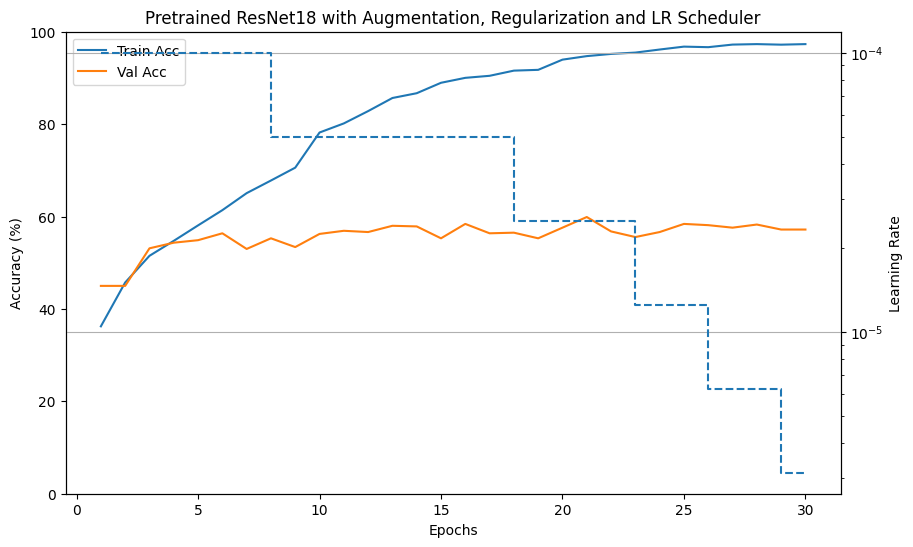


Final Test Accuracy: 64.50%


In [ ]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=30 # INCREASED
)

plot_history(history, "Pretrained ResNet18 with Augmentation, Regularization and LR Scheduler")

test_accuracy = evaluate_model(model, test_loader)